In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [24]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [25]:
# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [26]:
CANVAS = 75 # image is 75x75
OBJ = 28    # object inside image is 28x28 => size of region proposal

In [27]:
def make_localized_image(mnist_image):
    # Create a blank canvas (black background image to put the croped image on it)
    canvas = np.zeros((CANVAS, CANVAS), dtype=np.float32)
    # Randomly select a position for the object
    x1 = np.random.randint(0, CANVAS - OBJ + 1)   # random x position for the top-left corner of the object
    y1 = np.random.randint(0, CANVAS - OBJ + 1)   # random y position for the top-left corner of the object
    x2 = x1 + OBJ;
    y2 = y1 + OBJ;
    # Place the MNIST image onto the canvas
    canvas[y1:y2, x1:x2] = mnist_image  # place the 28x28 image on the canvas at the random position
    bbox = np.array([x1/CANVAS, y1/CANVAS, x2/CANVAS, y2/CANVAS])  # normalized bounding box coordinates with respect to image size (0->1)
    canvas = np.expand_dims(canvas, axis=-1)  # add channel dimension to the canvas (shape becomes (75, 75, 1)), cause mnist is 28x28x1

    return canvas, bbox
    

In [28]:
n_train = 12000
n_test = 2000

train_images = []
test_images = []
train_bboxes = []   # location task
test_bboxes = []
train_labels = []   # label task
test_labels = []

for i in range(n_train):
    img, bbox = make_localized_image(x_train[i])
    train_images.append(img)
    train_bboxes.append(bbox)        
    train_labels.append(y_train[i])

for i in range(n_test):
    img, bbox = make_localized_image(x_test[i])
    test_images.append(img)
    test_bboxes.append(bbox)        
    test_labels.append(y_test[i])               

In [29]:
train_images = np.array(train_images, dtype=np.float32)
test_images = np.array(test_images, dtype=np.float32)
train_bboxes = np.array(train_bboxes, dtype=np.float32)
test_bboxes = np.array(test_bboxes, dtype=np.float32)
train_labels = np.array(train_labels, dtype=np.int32)
test_labels = np.array(test_labels, dtype=np.int32)
print("Train images shape:", train_images.shape)  # (12000, 75, 75, 1)
print("Train bboxes shape:", train_bboxes.shape)  # (12000, 4)
print("Train labels shape:", train_labels.shape)  # (12000,)
print("Test images shape:", test_images.shape)    # (2000, 75, 75, 1)
print("Test bboxes shape:", test_bboxes.shape)    # (2000, 4)
print("Test labels shape:", test_labels.shape)    # (2000,)

Train images shape: (12000, 75, 75, 1)
Train bboxes shape: (12000, 4)
Train labels shape: (12000,)
Test images shape: (2000, 75, 75, 1)
Test bboxes shape: (2000, 4)
Test labels shape: (2000,)


In [30]:
inputs = tf.keras.Input(shape=(CANVAS, CANVAS, 1))

x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

bbox_output = tf.keras.layers.Dense(4, activation='sigmoid', name='location')(x)  # bounding box output with sigmoid activation to ensure values between 0 and 1 (x1,x2,y1,y2)
class_output = tf.keras.layers.Dense(10, activation='softmax', name='label')(x)  # label output with softmax activation for multi-class classification (10 classes for digits 0-9)

model = tf.keras.Model(inputs=inputs, outputs=[bbox_output, class_output])

print(model.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 73, 73,    │        160 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 36, 36,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 34, 34,    │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 17, 17,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 9248)      │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │  1,183,872 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location (Dense)    │ (None, 4)         │        516 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (Dense)       │ (None, 10)        │      1,290 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,190,478 (4.54 MB)

 Trainable params: 1,190,478 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

None


In [31]:
# Create a tf.data.Dataset for training by combining the images, bounding boxes, and labels into a single dataset object.
# to input multiple objects to the model
train_ds = tf.data.Dataset.from_tensor_slices((train_images, {'location': train_bboxes, 'label': train_labels}))
train_ds = train_ds.shuffle(buffer_size=1024).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, {'location': test_bboxes, 'label': test_labels}))
test_ds = test_ds.batch(32)

In [32]:
def iou_metric(y_true, y_pred):
    # y_true and y_pred are expected to be in the format [x1, y1, x2, y2] normalized to [0, 1]
    x1_true, y1_true, x2_true, y2_true = tf.split(y_true, 4, axis=-1)
    x1_pred, y1_pred, x2_pred, y2_pred = tf.split(y_pred, 4, axis=-1)

    # Calculate intersection
    x1_inter = tf.maximum(x1_true, x1_pred)
    y1_inter = tf.maximum(y1_true, y1_pred)
    x2_inter = tf.minimum(x2_true, x2_pred)
    y2_inter = tf.minimum(y2_true, y2_pred)

    inter_area = tf.maximum(0.0, x2_inter - x1_inter) * tf.maximum(0.0, y2_inter - y1_inter)

    # Calculate union
    true_area = (x2_true - x1_true) * (y2_true - y1_true)
    pred_area = (x2_pred - x1_pred) * (y2_pred - y1_pred)
    union_area = true_area + pred_area - inter_area

    # Calculate IoU
    iou = inter_area / (union_area + 1e-7)  # add small epsilon to avoid division by zero
    return tf.reduce_mean(iou)

In [36]:
model.compile(optimizer='adam',
              loss={'location': 'mse', 'label': 'sparse_categorical_crossentropy'},
              metrics={'location': ['mae', iou_metric], 'label': 'accuracy'})

In [38]:
model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - label_accuracy: 0.9894 - label_loss: 0.0308 - location_iou_metric: 0.7386 - location_loss: 0.0014 - location_mae: 0.0297 - loss: 0.0322 - val_label_accuracy: 0.8230 - val_label_loss: 0.7831 - val_location_iou_metric: 0.7435 - val_location_loss: 0.0014 - val_location_mae: 0.0293 - val_loss: 0.7824
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - label_accuracy: 0.9968 - label_loss: 0.0123 - location_iou_metric: 0.7490 - location_loss: 0.0013 - location_mae: 0.0283 - loss: 0.0136 - val_label_accuracy: 0.8130 - val_label_loss: 0.8289 - val_location_iou_metric: 0.7443 - val_location_loss: 0.0013 - val_location_mae: 0.0287 - val_loss: 0.8237
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - label_accuracy: 0.9935 - label_loss: 0.0245 - location_iou_metric: 0.7522 - location_loss: 0.0013 - location_mae: 0.0278 - loss: 0.0258 - val_label_accuracy: 0.8190 - val_label_loss: 0.8200 - val_location_iou_metric: 0.7429 - val_location_los

In [39]:
idx = 5
img = test_images[idx]
true_bbox = test_bboxes[idx]
true_label = test_labels[idx]
pred_bbox, pred_label = model.predict(np.expand_dims(img, axis=0))
pred_label = np.argmax(pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


In [41]:
pred_label = np.argmax(pred_label)
pred_label

np.int64(0)

In [43]:
true_label

np.int32(1)

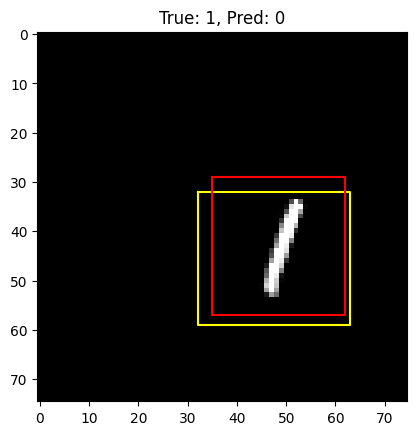

In [ ]:
plt.imshow(img.squeeze(), cmap='gray')
# Draw the predicted bounding box on the image
x1_pred = int(pred_bbox[0][0] * CANVAS)
y1_pred = int(pred_bbox[0][1] * CANVAS)
x2_pred = int(pred_bbox[0][2] * CANVAS)
y2_pred = int(pred_bbox[0][3] * CANVAS)
plt.plot([x1_pred, x2_pred, x2_pred, x1_pred, x1_pred], [y1_pred, y1_pred, y2_pred, y2_pred, y1_pred], color='yellow')  # draw the bounding box in red
# plot the true bounding box in red
x1_true = int(true_bbox[0] * CANVAS)
y1_true = int(true_bbox[1] * CANVAS)
x2_true = int(true_bbox[2] * CANVAS)
y2_true = int(true_bbox[3] * CANVAS)
plt.plot([x1_true, x2_true, x2_true, x1_true, x1_true], [y1_true, y1_true, y2_true, y2_true, y1_true], color='red')  # draw the bounding box in green
plt.title(f"True: {true_label}, Pred: {pred_label}")
plt.show()